In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
os.makedirs("outputs", exist_ok=True)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [15]:
CLASSES = ["airplane","automobile","bird","cat","deer",
           "dog","frog","horse","ship","truck"]

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

print(f"Train: {x_train.shape}  |  Test: {x_test.shape}")

augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1,0.1)
], name="augmentation" )

Train: (50000, 32, 32, 3)  |  Test: (10000, 32, 32, 3)


In [16]:
def build_cnn(input_shape=(32, 32, 3), num_classes=10, use_augmentation=True):
  inputs = keras.Input(shape=input_shape)
  x = augmentation(inputs) if use_augmentation else inputs


  x = layers.Conv2D(32, 3, padding="same", activation="relu", name="conv1_edges")(x)
  x = layers.BatchNormalization()(x)
  x = layers.Conv2D(32, 3, padding="same", activation="relu", name="conv2_edges")(x)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D(2, name="pool1")(x)
  x = layers.Dropout(0.2)(x)

  x = layers.Conv2D(64, 3, padding="same", activation="relu", name="conv3_shapes")(x)
  x = layers.BatchNormalization()(x)
  x = layers.Conv2D(64, 3, padding="same", activation="relu", name="conv4_shapes")(x)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D(2, name="pool2")(x)
  x = layers.Dropout(0.3)(x)

  x = layers.Conv2D(128, 3, padding="same", activation="relu", name="conv5_objects")(x)
  x = layers.BatchNormalization()(x)
  x = layers.Conv2D(128, 3, padding="same", activation="relu", name="last_conv")(x)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D(2, name="pool3")(x)
  x = layers.Dropout(0.4)(x)

  x = layers.Flatten()(x)
  x = layers.Dense(256, activation="relu")(x)
  x = layers.Dropout(0.5)(x)
  outputs = layers.Dense(num_classes, name="logits")(x)

  return keras.Model(inputs, outputs, name="cifar10_cnn")

model = build_cnn(use_augmentation=True)
model.summary()

Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_edges (Conv2D)            │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_edges (Conv2D)            │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_shapes (Conv2D)           │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_shapes (Conv2D)           │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5_objects (Conv2D)          │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,54

 Total params: 815,914 (3.11 MB)

 Trainable params: 815,018 (3.11 MB)

 Non-trainable params: 896 (3.50 KB)

In [18]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy", factor=0.5, patience=5, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        "outputs/best_model.keras", save_best_only=True,
        monitor="val_accuracy", verbose=1
    ),
]

EPOCHS = 20 # Changed from 40 to 20
BATCH = 128 # Changed from 64 to 128
history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1,
)

model = keras.models.load_model("outputs/best_model.keras")

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nFinal test accuracy: {test_acc:.1%}")

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - accuracy: 0.2471 - loss: 2.2503
Epoch 1: val_accuracy improved from None to 0.11580, saving model to outputs/best_model.keras

Epoch 1: finished saving model to outputs/best_model.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 239s 669ms/step - accuracy: 0.3005 - loss: 1.9375 - val_accuracy: 0.1158 - val_loss: 3.4406 - learning_rate: 0.0010
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.3861 - loss: 1.6768
Epoch 2: val_accuracy improved from 0.11580 to 0.47100, saving model to outputs/best_model.keras

Epoch 2: finished saving model to outputs/best_model.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 269s 691ms/step - accuracy: 0.4002 - loss: 1.6421 - val_accuracy: 0.4710 - val_loss: 1.4401 - learning_rate: 0.0010
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.4427 - loss: 1.5380
Epoch 3: val_accuracy improved from 0.47100 to 0.50160, saving model to outputs/best_model.keras

Epoch 3: finished saving model to out

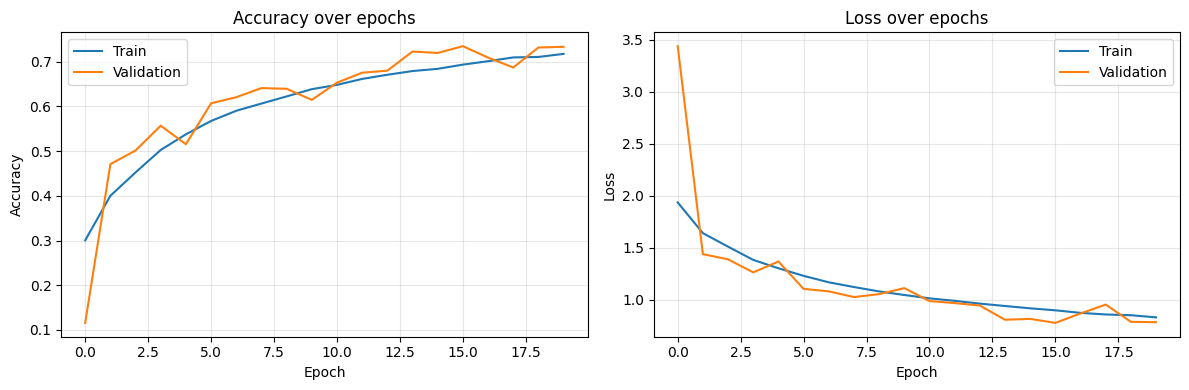

Saved: outputs/training_history.png


In [19]:
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["accuracy"], label="Train")
    axes[0].plot(history.history["val_accuracy"], label="Validation")
    axes[0].set_title("Accuracy over epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history.history["loss"], label="Train")
    axes[1].plot(history.history["val_loss"], label="Validation")
    axes[1].set_title("Loss over epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("outputs/training_history.png", dpi=150)
    plt.show()
    print("Saved: outputs/training_history.png")

plot_history(history)

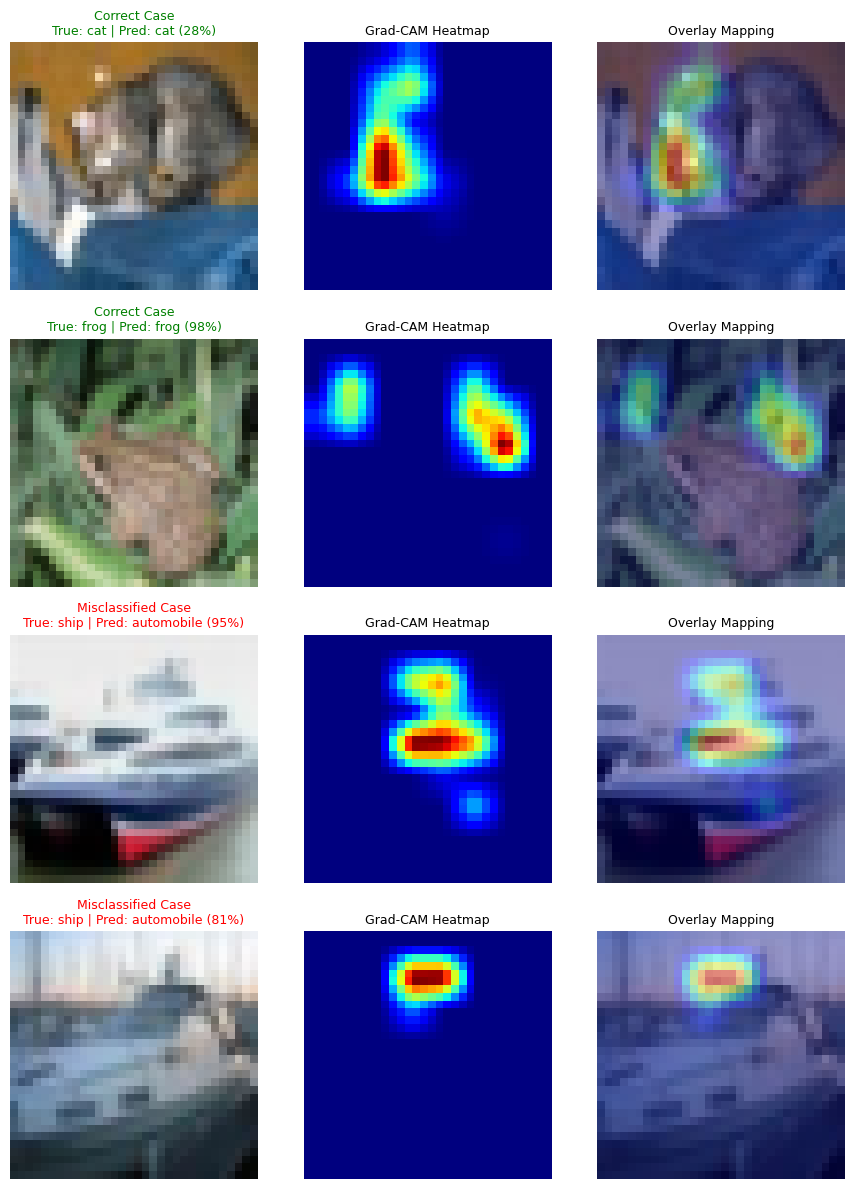

In [24]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="last_conv"):
    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output],
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_class = tf.argmax(predictions[0])
        class_score = predictions[:, pred_class]

    grads = tape.gradient(class_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    # Fixed matrix multiplication dimension alignment
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    heatmap = tf.nn.relu(heatmap)
    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap = heatmap / max_val
    return heatmap.numpy(), int(pred_class), predictions.numpy()

def overlay_gradcam(image, heatmap, alpha=0.4):
    heatmap_resized = np.array(
        tf.image.resize(heatmap[..., np.newaxis], (image.shape[0], image.shape[1]))
    ).squeeze()
    colormap = plt.colormaps.get_cmap("jet")
    colored = colormap(heatmap_resized)[:, :, :3]
    overlay = (1 - alpha) * image + alpha * colored
    overlay = np.clip(overlay, 0, 1)
    return overlay, heatmap_resized

def visualize_gradcam(model, x_test, y_test, n_correct=2, n_wrong=2):
    logits = model.predict(x_test, verbose=0)
    probs = tf.nn.softmax(logits).numpy()
    preds = np.argmax(probs, axis=1)
    labels = y_test.squeeze()

    correct_idx = np.where(preds == labels)[0]
    wrong_idx = np.where(preds != labels)[0]

    n_cols = 3
    n_rows = n_correct + n_wrong
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(9, n_rows * 3))

    def plot_row(ax_row, idx, row_label):
        img = x_test[idx]
        true = labels[idx]
        pred, conf = preds[idx], probs[idx].max()

        img_batch = img[np.newaxis, ...]
        heatmap, _, _ = make_gradcam_heatmap(img_batch, model)
        overlay, hm_resized = overlay_gradcam(img, heatmap)

        ax_row[0].imshow(img)
        ax_row[0].set_title(f"{row_label}\nTrue: {CLASSES[true]} | Pred: {CLASSES[pred]} ({conf:.0%})",
                            fontsize=9, color="green" if true == pred else "red")
        ax_row[0].axis("off")

        ax_row[1].imshow(hm_resized, cmap="jet")
        ax_row[1].set_title("Grad-CAM Heatmap", fontsize=9)
        ax_row[1].axis("off")

        ax_row[2].imshow(overlay)
        ax_row[2].set_title("Overlay Mapping", fontsize=9)
        ax_row[2].axis("off")

    for i, idx in enumerate(correct_idx[:n_correct]):
        plot_row(axes[i], idx, "Correct Case")
    for i, idx in enumerate(wrong_idx[:n_wrong]):
        plot_row(axes[n_correct + i], idx, "Misclassified Case")

    plt.tight_layout()
    plt.savefig("outputs/gradcam_visualization.png", dpi=150, bbox_inches="tight")
    plt.show()

visualize_gradcam(model, x_test, y_test)

/tmp/ipykernel_879/3554360428.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true = int(y_test[idx])
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_4']
Received: inputs=Tensor(shape=(1, 32, 32, 3))
  warnings.warn(msg)
/tmp/ipykernel_879/552101886.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("jet")


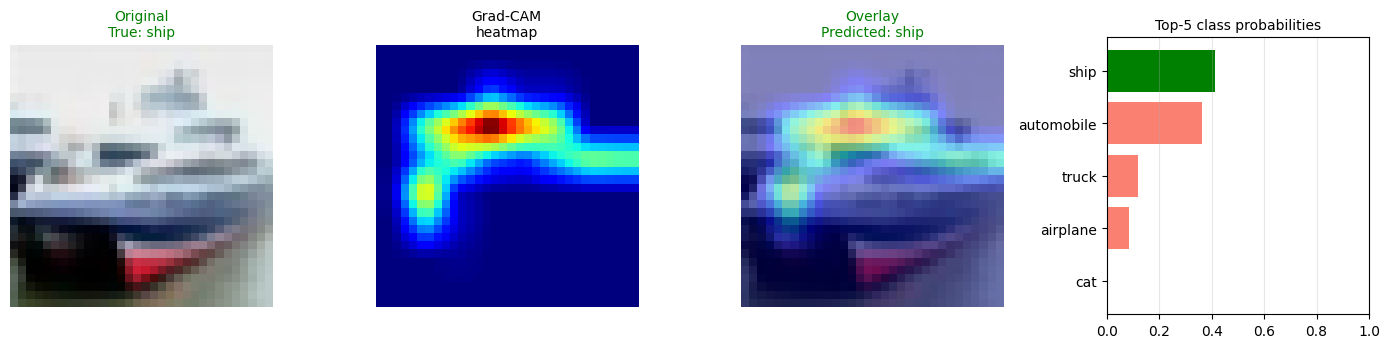

Saved: outputs/deep_dive.png

  Prediction: ship (41.4% confidence)
  True label: ship
  Result : CORRECT

  Grad-CAM insight: the model correctly focused on ship features.



In [21]:
def deep_dive(model, x_test, y_test, idx=None):
  if idx is None:
        logits = model.predict(x_test[:1000], verbose=0)
        preds = np.argmax(tf.nn.softmax(logits), axis=1)
        wrong = np.where(preds != y_test[:1000].squeeze())[0]
        idx = wrong[0] if len(wrong) > 0 else 0

  img = x_test[idx]
  true = int(y_test[idx])

  img_batch = img[np.newaxis, ...]
  heatmap, pred_class, raw_logits = make_gradcam_heatmap(img_batch, model)
  overlay, hm_resized = overlay_gradcam(img, heatmap)

  probs = tf.nn.softmax(raw_logits[0]).numpy()
  top5_idx = np.argsort(probs)[::-1][:5]

  fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
  axes[0].imshow(img)
  axes[0].set_title(
      f"Original\nTrue: {CLASSES[true]}", fontsize=10,
      color="green" if true == pred_class else "red"
  )
  axes[0].axis("off")

  axes[1].imshow(hm_resized, cmap="jet")
  axes[1].set_title("Grad-CAM\nheatmap", fontsize=10)
  axes[1].axis("off")

  axes[2].imshow(overlay)
  axes[2].set_title(
      f"Overlay\nPredicted: {CLASSES[pred_class]}", fontsize=10,
      color="green" if true == pred_class else "red"
  )
  axes[2].axis("off")

  bars = axes[3].barh(
      [CLASSES[i] for i in top5_idx],
      [probs[i] for i in top5_idx],
      color=["green" if i == true else "salmon" for i in top5_idx],
  )
  axes[3].set_xlim(0, 1)
  axes[3].set_title("Top-5 class probabilities", fontsize=10)
  axes[3].invert_yaxis()
  axes[3].grid(axis="x", alpha=0.3)

  plt.tight_layout()
  plt.savefig("outputs/deep_dive.png", dpi=150, bbox_inches="tight")
  plt.show()
  print("Saved: outputs/deep_dive.png")

  correct = "CORRECT" if pred_class == true else "WRONG"
  print(f"\n{'='*50}")
  print(f"  Prediction: {CLASSES[pred_class]} ({probs[pred_class]:.1%} confidence)")
  print(f"  True label: {CLASSES[true]}")
  print(f"  Result : {correct}")
  if pred_class != true:
      print(f"\n  Grad-CAM insight: the model focused on the WRONG region.")
      print(f"  It saw {CLASSES[pred_class]}-like features but missed the actual {CLASSES[true]}.")
  else:
      print(f"\n  Grad-CAM insight: the model correctly focused on {CLASSES[true]} features.")
  print(f"{'='*50}\n")

deep_dive(model, x_test, y_test)